<a href="https://colab.research.google.com/github/Anderoids/Anderoids/blob/main/MajorProj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
%%bash
pip install -U pip setuptools wheel

pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
pip install -q rasterio opencv-python matplotlib scikit-image pillow
pip install -q git+https://github.com/openai/CLIP.git
pip install -q segment-anything || true

python - <<'PY'
import sys,torch
import rasterio,skimage
import clip
print("python", sys.version.split()[0])
print("torch", torch.__version__)
print("rasterio", rasterio.__version__)
print("skimage", skimage.__version__)
print("clip imported")
PY

python 3.12.12
torch 2.10.0+cu128
rasterio 1.5.0
skimage 0.25.2
clip imported


# Import Libraries

In [11]:
# Cell 2
import os, io, math, tempfile
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import rasterio
from rasterio.plot import show
import cv2
import torch
import clip   # from openai/CLIP
from skimage.segmentation import slic
from skimage.color import label2rgb
from skimage.measure import regionprops
from sklearn.metrics import precision_recall_fscore_support, jaccard_score

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# small helper to show images side-by-side
def imshow_pair(a, b, cmap='viridis', titles=('A','B'), figsize=(12,6)):
    plt.figure(figsize=figsize)
    plt.subplot(1,2,1); plt.imshow(a, cmap=cmap); plt.title(titles[0]); plt.axis('off')
    plt.subplot(1,2,2); plt.imshow(b, cmap=cmap); plt.title(titles[1]); plt.axis('off')
    plt.show()

device: cuda


# Load your Sentinel files

/content/drive/MyDrive/data/sentinel_before.tif exists? True
/content/drive/MyDrive/data/sentinel_after.tif exists? True
/content/drive/MyDrive/data/gfc_loss_mask.tif exists? True
before shape (bands,H,W): (24, 5567, 5567)
after shape (bands,H,W): (24, 5567, 5567)


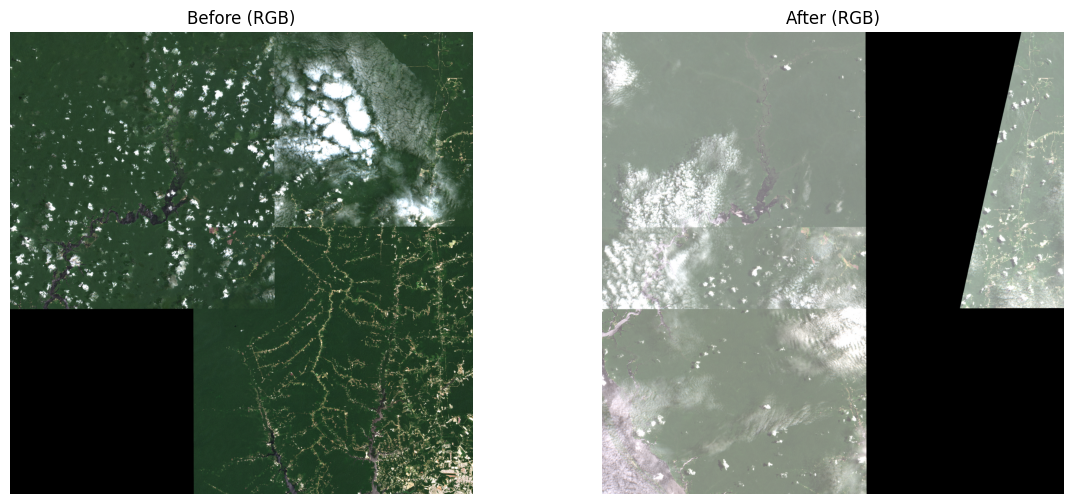

In [12]:
# Cell 3 — paths: change if files are in a folder
before_path = "/content/drive/MyDrive/data/sentinel_before.tif"
after_path  = "/content/drive/MyDrive/data/sentinel_after.tif"
gt_path     = "/content/drive/MyDrive/data/gfc_loss_mask.tif"

# quick existence check
for p in [before_path, after_path, gt_path]:
    print(p, "exists?", os.path.exists(p))

# helper: read raster and return array (H,W,C) with bands in natural order if possible
def read_raster_rgb_preview(path, red_idx=None, green_idx=None, blue_idx=None):
    """Read raster; if band indices provided (1-based) use them, else try Sentinel-2 default mapping.
    Returns (arr, profile) where arr is float32 HxWxC (C = all bands), and rgb uint8 preview if possible.
    """
    src = rasterio.open(path)
    arr = src.read().astype('float32')  # shape: (bands, H, W)
    profile = src.profile
    # try to make RGB preview using common Sentinel-2 layout: B4=red (index 4), B3=green (3), B2=blue (2)
    if red_idx is None:
        red_idx, green_idx, blue_idx = 4, 3, 2
    try:
        rgb = np.stack([arr[red_idx-1], arr[green_idx-1], arr[blue_idx-1]], axis=-1)
        # normalize to 0-255 for display
        def to_uint8(x):
            x = np.nan_to_num(x)
            mi, ma = np.percentile(x, 2), np.percentile(x, 98)
            x = (x - mi) / (ma - mi + 1e-9)
            x = np.clip(x, 0, 1)
            return (255 * x).astype('uint8')
        rgb_u8 = np.stack([to_uint8(rgb[...,i]) for i in range(3)], axis=-1)
    except Exception as e:
        print("Could not make RGB preview:", e)
        rgb_u8 = None
    return arr, profile, rgb_u8

before_arr, before_profile, before_rgb = read_raster_rgb_preview(before_path)
after_arr, after_profile, after_rgb = read_raster_rgb_preview(after_path)

print("before shape (bands,H,W):", before_arr.shape)
print("after shape (bands,H,W):", after_arr.shape)

# show a quick RGB preview if available
if before_rgb is not None and after_rgb is not None:
    imshow_pair(before_rgb, after_rgb, titles=('Before (RGB)', 'After (RGB)'), figsize=(14,6))
else:
    print("No RGB previews available; continuing with band arrays.")